# Ablation analysis.

In [1]:
import  numpy as np
import matplotlib        as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import scipy.stats

sns.set_style("ticks")

mpl.rcParams['font.family'] = ['serif']
mpl.rcParams['mathtext.fontset'] = 'dejavuserif'
mpl.rcParams['font.size'] = 8.

cm = 1/2.54  # centimeters in inches
colors = ["#EDA3B2", "#7E73AC", "#69bf0d", "#b5978b", "#B3B3B3"]

In [2]:
tasks = {'no_reglosses_causes_clashes':     ('clashes',  ('-plddt', '-anchoring-plddt', '-cistogram-plddt', '-rigidbody-plddt')),
         'repelling_vs_anchoring':          ('rmsd',     ('-plddt', 'anchor_only', 'repel_only')),
         'repelling_vs_plddt':              ('rmsd', ('full', '-plddt', '-repel_plddt1', '-repel_plddt5', '-repel_plddt10')), }

labels = {          '-plddt': r"AFLF$-\mathcal{L}_{\mathrm{pLDDT}}$", 
          '-anchoring-plddt': r"AFLF$-\mathcal{L}_{\mathrm{pLDDT}}-\mathcal{L}_{\mathrm{anchoring}}$", 
          '-cistogram-plddt': r"AFLF$-\mathcal{L}_{\mathrm{pLDDT}}-\mathcal{L}_{\mathrm{global}}$", 
          '-rigidbody-plddt': r"AFLF$-\mathcal{L}_{\mathrm{pLDDT}}-\mathcal{L}_{\mathrm{local}}$", 
          'anchor_only': r"$\mathcal{L}_{\mathrm{anchoring}}$", 
           'repel_only': r"$\mathcal{L}_{\mathrm{repelling}}$", 
           'full': r"AFLF",
          '-repel_plddt1':  r"AFLF$-\mathcal{L}_{\mathrm{repelling}}$; $w_{\mathrm{pLDDT}}=1$", 
          '-repel_plddt5':  r"AFLF$-\mathcal{L}_{\mathrm{repelling}}$; $w_{\mathrm{pLDDT}}=5$",
          '-repel_plddt10': r"AFLF$-\mathcal{L}_{\mathrm{repelling}}$; $w_{\mathrm{pLDDT}}=10$", }

sysnames = ['0_ubq', '1_adk', '2_tem1']

# pname - profile_name

def load_clashes(tname: str, sname: str, pname: str) -> tuple[np.ndarray, np.ndarray]:
  assert sname in sysnames
  assert pname in tasks[tname][1]
  with open(f"./zcsvs/{tname}/clashes_{sname}_{pname}.csv", 'r') as f:
    lines = f.readlines()
  frames  = np.asarray([int(line.split(',')[0].strip()) for line in lines])
  clashes = np.asarray([int(line.split(',')[1].strip()) for line in lines])
  return frames, clashes

def load_rmsds(tname: str, sname: str, pname: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
  assert sname in sysnames
  assert pname in tasks[tname][1]
  with open(f"./zcsvs/{tname}/rmsd_{sname}_{pname}.csv", 'r') as f:
    lines = f.readlines()
  frames   = np.asarray([  int(line.split(',')[0].strip()) for line in lines])
  rmsdinit = np.asarray([float(line.split(',')[1].strip()) for line in lines])
  rmsdprev = np.asarray([float(line.split(',')[2].strip()) for line in lines])
  return frames, rmsdinit, rmsdprev

def get_stars(p_value: float):
    if   p_value < 0.001: return '***'
    elif p_value < 0.01 : return '**'
    elif p_value < 0.05 : return '*'
    else:                 return 'ns'

def block_mean(x: np.ndarray, n_block: int = 200) -> np.ndarray:
  k = len(x) // n_block
  return x[:k * n_block].reshape(k, n_block).mean(axis=1)

15.0 13.0


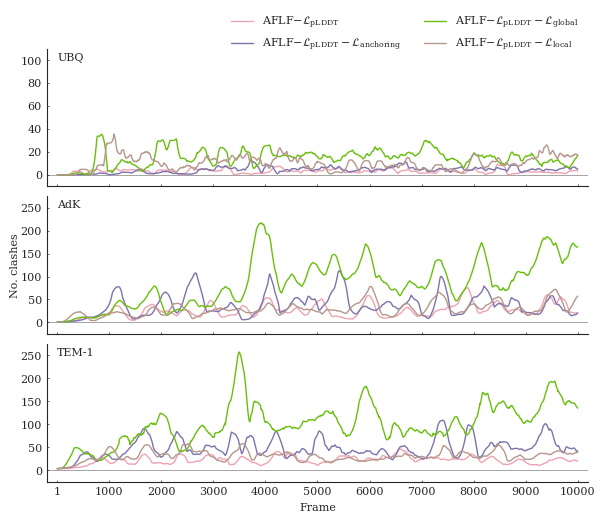

In [3]:
# PLOT no_reglosses_causes_clashes
figspec= {'lmargin': 1  *cm, 
          'rmargin': 1/4*cm,
          'hgap':    1/4*cm,
          'hsize':  55/4*cm,
          'bmargin': 1  *cm,
          'tmargin': 1  *cm,
          'vgap':    1/4*cm,
          'vsize':  14/4*cm,}

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*2 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True, sharey=False,
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))

for ax in axes:
  ax.minorticks_off()
  ax.spines[['top','right']].set_visible(False)
  ax.tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)
  ax.set(xlim=(-200, 10200), xticks=(1, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000))
  ax.axhline(y=0, color='#808080', ls='-', lw=0.5, zorder=0)

out_ubq = {p: load_clashes(tname='no_reglosses_causes_clashes', sname='0_ubq', pname=p) for p in tasks['no_reglosses_causes_clashes'][1]}
for i, (k, v) in enumerate(out_ubq.items()):
  axes[0].plot(v[0]+1, np.convolve(np.pad(v[1], (99, 100), mode='edge'), np.ones(200)/200, mode='valid'), color=colors[i], ls='-', lw=1., label=labels[k])
axes[0].set(ylim=(-10, 110), yticks=(0, 20, 40, 60, 80, 100))
axes[0].text(0, 100, 'UBQ')

out_adk = {p: load_clashes(tname='no_reglosses_causes_clashes', sname='1_adk', pname=p) for p in tasks['no_reglosses_causes_clashes'][1]}
for i, (k, v) in enumerate(out_adk.items()):
  axes[1].plot(v[0]+1, np.convolve(np.pad(v[1], (99, 100), mode='edge'), np.ones(200)/200, mode='valid'), color=colors[i], ls='-', lw=1., label=labels[k])
axes[1].set(ylim=(-25, 275), yticks=(0, 50, 100, 150, 200, 250))
axes[1].text(0, 250, 'AdK')

out_tem1 = {p: load_clashes(tname='no_reglosses_causes_clashes', sname='2_tem1', pname=p) for p in tasks['no_reglosses_causes_clashes'][1]}
for i, (k, v) in enumerate(out_tem1.items()):
  axes[2].plot(v[0]+1, np.convolve(np.pad(v[1], (99, 100), mode='edge'), np.ones(200)/200, mode='valid'), color=colors[i], ls='-', lw=1., label=labels[k])
axes[2].set(ylim=(-25, 275), yticks=(0, 50, 100, 150, 200, 250))
axes[2].text(0, 250, 'TEM-1')

axes[0].legend(frameon=False, ncol=2, loc='lower right', bbox_to_anchor=(1.0, 0.9))
axes[1].set_ylabel(r'No. clashes', fontsize=8, va='center')
axes[2].set_xlabel(r'Frame', fontsize=8, ha='center')
plt.savefig(f'./zfigures/fig_no_reglosses_causes_clashes.jpg', dpi=600)

6.999999999999999 3.25
6.999999999999999 3.25


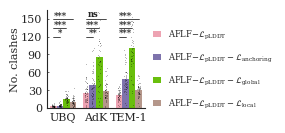

In [11]:
figspec= {'lmargin':  4/4*cm, 
          'rmargin': 14/4*cm,
          'hgap':    0  *cm,
          'hsize':  10/4*cm,
          'bmargin': 1/2*cm,
          'tmargin': 1/4*cm,
          'vgap':    0  *cm,
          'vsize':  10/4*cm,}

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*0 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*0 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

fig, ax = plt.subplots(1, 1, figsize=figsize, sharex=True, sharey=False,
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))
ax.minorticks_off()
ax.spines[['top','right']].set_visible(False)
ax.tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)
ax.set(xlim=(-1, 5), xticks=(0, 2, 4), xticklabels=['UBQ', 'AdK', 'TEM-1'],
       ylim=(0, 165), yticks=np.arange(0, 151, 30), )

ax.axhline(y=0, color='#808080', ls='-', lw=0.5, zorder=0)
  
out_ubq  = {p: load_clashes(tname='no_reglosses_causes_clashes', sname='0_ubq',  pname=p) for p in tasks['no_reglosses_causes_clashes'][1]}
out_adk  = {p: load_clashes(tname='no_reglosses_causes_clashes', sname='1_adk',  pname=p) for p in tasks['no_reglosses_causes_clashes'][1]}
out_tem1 = {p: load_clashes(tname='no_reglosses_causes_clashes', sname='2_tem1', pname=p) for p in tasks['no_reglosses_causes_clashes'][1]}
outs = [out_ubq, out_adk, out_tem1]
keys = list(out_ubq.keys())
width = .4

# bars.
for i, k in enumerate(keys):
    xs_i = np.arange(3) * 2 - 0.6 + width * i
    heights = [outs[s][k][1].mean() for s in range(3)]
    ax.bar(xs_i, heights, width=width, lw=0., color=colors[i], label=labels[k])
# points.
for i_bar in range(3):
  ax.scatter(i_bar*2-.6+np.random.uniform(-0.08, 0.08, size=block_mean(outs[i_bar][keys[0]][1]).shape[0]), block_mean(outs[i_bar][keys[0]][1]), s=.1, lw=0, c="k")
  ax.scatter(i_bar*2-.2+np.random.uniform(-0.08, 0.08, size=block_mean(outs[i_bar][keys[1]][1]).shape[0]), block_mean(outs[i_bar][keys[1]][1]), s=.1, lw=0, c="k")
  ax.scatter(i_bar*2+.2+np.random.uniform(-0.08, 0.08, size=block_mean(outs[i_bar][keys[2]][1]).shape[0]), block_mean(outs[i_bar][keys[2]][1]), s=.1, lw=0, c="k")
  ax.scatter(i_bar*2+.6+np.random.uniform(-0.08, 0.08, size=block_mean(outs[i_bar][keys[3]][1]).shape[0]), block_mean(outs[i_bar][keys[3]][1]), s=.1, lw=0, c="k")
# stat sigs.
for i_bar in range(3):
  _, p01 = scipy.stats.ttest_ind(block_mean(outs[i_bar][keys[0]][1]), block_mean(outs[i_bar][keys[1]][1]), equal_var=False)
  _, p02 = scipy.stats.ttest_ind(block_mean(outs[i_bar][keys[0]][1]), block_mean(outs[i_bar][keys[2]][1]), equal_var=False)
  _, p03 = scipy.stats.ttest_ind(block_mean(outs[i_bar][keys[0]][1]), block_mean(outs[i_bar][keys[3]][1]), equal_var=False)
  ax.plot((i_bar*2-.6, i_bar*2-.2), [120, 120], 'k-', lw=0.5)
  ax.plot((i_bar*2-.6, i_bar*2+.2), [135, 135], 'k-', lw=0.5)
  ax.plot((i_bar*2-.6, i_bar*2+.6), [150, 150], 'k-', lw=0.5)
  ax.text( i_bar*2-.2, 118+(2 if get_stars(p_value=p01)=='ns' else 0), get_stars(p_value=p01), ha='center', va='bottom', fontsize=6, fontweight='bold')
  ax.text( i_bar*2-.2, 133+(2 if get_stars(p_value=p02)=='ns' else 0), get_stars(p_value=p02), ha='center', va='bottom', fontsize=6, fontweight='bold')
  ax.text( i_bar*2-.2, 148+(2 if get_stars(p_value=p03)=='ns' else 0), get_stars(p_value=p03), ha='center', va='bottom', fontsize=6, fontweight='bold')


ax.legend(frameon=False, ncol=1, loc='lower left', bbox_to_anchor=(1.0, -.1), fontsize=6, handlelength=1., labelspacing=1.2)
ax.set_ylabel(r'No. clashes', fontsize=8, va='center')
plt.savefig(f'./zfigures/fig_no_reglosses_causes_clashes_bar.jpg', dpi=600)

15.0 9.999999999999998


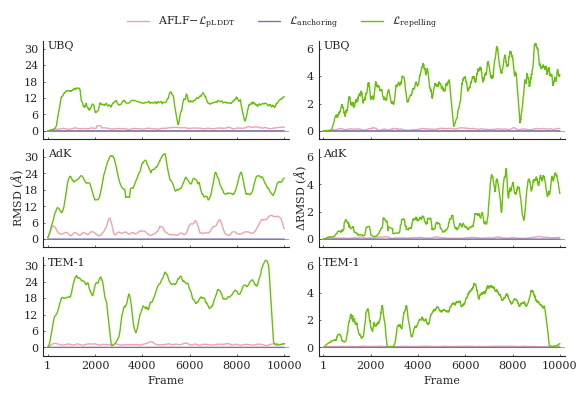

In [5]:
# PLOT no_reglosses_causes_clashes
figspec= {'lmargin': 1  *cm, 
          'rmargin': 3/4*cm,
          'hgap':    3/4*cm,
          'hsize':  25/4*cm,
          'bmargin': 1  *cm,
          'tmargin': 1  *cm,
          'vgap':    1/4*cm,
          'vsize':  10/4*cm,}

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*1 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*2 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

fig, axes = plt.subplots(3, 2, figsize=figsize, sharex=True, sharey=False,
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))
axes = axes.flatten()
for ax in axes:
  ax.minorticks_off()
  ax.spines[['top','right']].set_visible(False)
  ax.tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)
  ax.set(xlim=(-200, 10200), xticks=(1, 2000, 4000, 6000, 8000, 10000))
  ax.axhline(y=0, color='#808080', ls='-', lw=0.5, zorder=0)

out_ubq = {p: load_rmsds(tname='repelling_vs_anchoring', sname='0_ubq', pname=p) for p in tasks['repelling_vs_anchoring'][1]}
for i, (k, v) in enumerate(out_ubq.items()):
  axes[0].plot(v[0]+1, np.convolve(np.pad(v[1], (99, 100), mode='edge'), np.ones(200)/200, mode='valid'), color=colors[i], ls='-', lw=1., label=labels[k])
axes[0].set(ylim=(-3, 33), yticks=(0, 6, 12, 18, 24, 30))
axes[0].text(0, 30, 'UBQ')
for i, (k, v) in enumerate(out_ubq.items()):
  axes[1].plot(v[0]+1, np.convolve(np.pad(v[2], (99, 100), mode='edge'), np.ones(200)/200, mode='valid'), color=colors[i], ls='-', lw=1., label=labels[k])
axes[1].set(ylim=(-.6, 6.6), yticks=(0, 2, 4, 6))
axes[1].text(0, 6, 'UBQ')

out_adk = {p: load_rmsds(tname='repelling_vs_anchoring', sname='1_adk', pname=p) for p in tasks['repelling_vs_anchoring'][1]}
for i, (k, v) in enumerate(out_adk.items()):
  axes[2].plot(v[0]+1, np.convolve(np.pad(v[1], (99, 100), mode='edge'), np.ones(200)/200, mode='valid'), color=colors[i], ls='-', lw=1., label=labels[k])
axes[2].set(ylim=(-3, 33), yticks=(0, 6, 12, 18, 24, 30))
axes[2].text(0, 30, 'AdK')

for i, (k, v) in enumerate(out_adk.items()):
  axes[3].plot(v[0]+1, np.convolve(np.pad(v[2], (99, 100), mode='edge'), np.ones(200)/200, mode='valid'), color=colors[i], ls='-', lw=1., label=labels[k])
axes[3].set(ylim=(-.6, 6.6), yticks=(0, 2, 4, 6))
axes[3].text(0, 6, 'AdK')

out_tem1 = {p: load_rmsds(tname='repelling_vs_anchoring', sname='2_tem1', pname=p) for p in tasks['repelling_vs_anchoring'][1]}
for i, (k, v) in enumerate(out_tem1.items()):
  axes[4].plot(v[0]+1, np.convolve(np.pad(v[1], (99, 100), mode='edge'), np.ones(200)/200, mode='valid'), color=colors[i], ls='-', lw=1., label=labels[k])
axes[4].set(ylim=(-3, 33), yticks=(0, 6, 12, 18, 24, 30))
axes[4].text(0, 30, 'TEM-1')

for i, (k, v) in enumerate(out_tem1.items()):
  axes[5].plot(v[0]+1, np.convolve(np.pad(v[2], (99, 100), mode='edge'), np.ones(200)/200, mode='valid'), color=colors[i], ls='-', lw=1., label=labels[k])
axes[5].set(ylim=(-.6, 6.6), yticks=(0, 2, 4, 6))
axes[5].text(0, 6, 'TEM-1')

axes[1].legend(frameon=False, ncol=3, loc='lower center', bbox_to_anchor=(-.15, 1.0))
axes[2].set_ylabel(r'RMSD ($\AA$)', fontsize=8, va='center')
axes[3].set_ylabel(r'$\Delta$RMSD ($\AA$)', fontsize=8, va='center')
axes[4].set_xlabel(r'Frame', fontsize=8, ha='center')
axes[5].set_xlabel(r'Frame', fontsize=8, ha='center')
plt.savefig(f'./zfigures/fig_repelling_vs_anchoring.jpg', dpi=600)

15.0 9.999999999999998


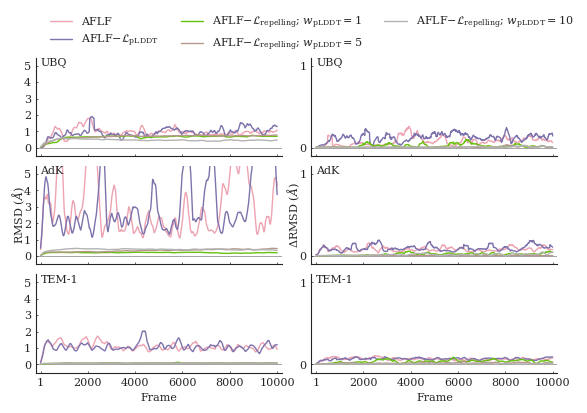

In [8]:
# PLOT no_reglosses_causes_clashes
figspec= {'lmargin': 1  *cm, 
          'rmargin': 3/4*cm,
          'hgap':    3/4*cm,
          'hsize':  25/4*cm,
          'bmargin': 1  *cm,
          'tmargin': 1  *cm,
          'vgap':    1/4*cm,
          'vsize':  10/4*cm,}

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*1 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*2 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

fig, axes = plt.subplots(3, 2, figsize=figsize, sharex=True, sharey=False,
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))
axes = axes.flatten()
for ax in axes:
  ax.minorticks_off()
  ax.spines[['top','right']].set_visible(False)
  ax.tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)
  ax.set(xlim=(-200, 10200), xticks=(1, 2000, 4000, 6000, 8000, 10000))
  ax.axhline(y=0, color='#808080', ls='-', lw=0.5, zorder=0)

out_ubq = {p: load_rmsds(tname='repelling_vs_plddt', sname='0_ubq', pname=p) for p in tasks['repelling_vs_plddt'][1]}
for i, (k, v) in enumerate(out_ubq.items()):
  axes[0].plot(v[0]+1, np.convolve(np.pad(v[1], (99, 100), mode='edge'), np.ones(200)/200, mode='valid'), color=colors[i], ls='-', lw=1., label=labels[k])
axes[0].set(ylim=(-.5, 5.5), yticks=(0, 1, 2, 3, 4, 5))
axes[0].text(0, 5, 'UBQ')
for i, (k, v) in enumerate(out_ubq.items()):
  axes[1].plot(v[0]+1, np.convolve(np.pad(v[2], (99, 100), mode='edge'), np.ones(200)/200, mode='valid'), color=colors[i], ls='-', lw=1., label=labels[k])
axes[1].set(ylim=(-.1, 1.1), yticks=(0, 1.))
axes[1].text(0, 1, 'UBQ')

out_adk = {p: load_rmsds(tname='repelling_vs_plddt', sname='1_adk', pname=p) for p in tasks['repelling_vs_plddt'][1]}
for i, (k, v) in enumerate(out_adk.items()):
  axes[2].plot(v[0]+1, np.convolve(np.pad(v[1], (99, 100), mode='edge'), np.ones(200)/200, mode='valid'), color=colors[i], ls='-', lw=1., label=labels[k])
axes[2].set(ylim=(-.5, 5.5), yticks=(0, 1, 2, 3, 4, 5))
axes[2].text(0, 5, 'AdK')

for i, (k, v) in enumerate(out_adk.items()):
  axes[3].plot(v[0]+1, np.convolve(np.pad(v[2], (99, 100), mode='edge'), np.ones(200)/200, mode='valid'), color=colors[i], ls='-', lw=1., label=labels[k])
axes[3].set(ylim=(-.1, 1.1), yticks=(0, 1.))
axes[3].text(0, 1, 'AdK')

out_tem1 = {p: load_rmsds(tname='repelling_vs_plddt', sname='2_tem1', pname=p) for p in tasks['repelling_vs_plddt'][1]}
for i, (k, v) in enumerate(out_tem1.items()):
  axes[4].plot(v[0]+1, np.convolve(np.pad(v[1], (99, 100), mode='edge'), np.ones(200)/200, mode='valid'), color=colors[i], ls='-', lw=1., label=labels[k])
axes[4].set(ylim=(-.5, 5.5), yticks=(0, 1, 2, 3, 4, 5))
axes[4].text(0, 5, 'TEM-1')

for i, (k, v) in enumerate(out_tem1.items()):
  axes[5].plot(v[0]+1, np.convolve(np.pad(v[2], (99, 100), mode='edge'), np.ones(200)/200, mode='valid'), color=colors[i], ls='-', lw=1., label=labels[k])
axes[5].set(ylim=(-.1, 1.1), yticks=(0, 1.))
axes[5].text(0, 1, 'TEM-1')

axes[1].legend(frameon=False, ncol=3, loc='lower center', bbox_to_anchor=(-.0, .95))
axes[2].set_ylabel(r'RMSD ($\AA$)', fontsize=8, va='center')
axes[3].set_ylabel(r'$\Delta$RMSD ($\AA$)', fontsize=8, va='center')
axes[4].set_xlabel(r'Frame', fontsize=8, ha='center')
axes[5].set_xlabel(r'Frame', fontsize=8, ha='center')
plt.savefig(f'./zfigures/fig_repelling_vs_plddt.jpg', dpi=600)

8.0 3.25
8.0 3.25


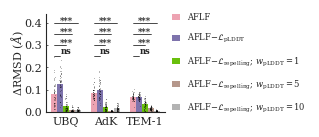

In [12]:
figspec= {'lmargin':  5/4 *cm, 
          'rmargin': 15/4*cm,
          'hgap':    0  *cm,
          'hsize':  12/4*cm,
          'bmargin': 1/2*cm,
          'tmargin': 1/4*cm,
          'vgap':    0  *cm,
          'vsize':  10/4*cm,}

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*0 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

figsize = (figspec['lmargin'] + figspec['hsize'] + (figspec['hgap']+figspec['hsize'])*0 + figspec['rmargin'], 
           figspec['bmargin'] + figspec['vsize'] + (figspec['vgap']+figspec['vsize'])*0 + figspec['tmargin'], )
print(figsize[0]/cm, figsize[1]/cm)

fig, ax = plt.subplots(1, 1, figsize=figsize, sharex=True, sharey=False,
    gridspec_kw=dict(left  =figspec['lmargin']/figsize[0], right=1.-figspec['rmargin']/figsize[0],
                     bottom=figspec['bmargin']/figsize[1], top  =1.-figspec['tmargin']/figsize[1],
                     wspace=figspec['hgap']/figspec['hsize'],
                     hspace=figspec['vgap']/figspec['vsize'], ))
ax.minorticks_off()
ax.spines[['top','right']].set_visible(False)
ax.tick_params(direction='in', width=.5, length=1.5, axis='both', labelsize=8)
ax.set(xlim=(-1, 5), xticks=(0, 2, 4), xticklabels=['UBQ', 'AdK', 'TEM-1'],
       ylim=(0, .44), yticks=np.arange(0, .41, .1), )

ax.axhline(y=0, color='#808080', ls='-', lw=0.5, zorder=0)

out_ubq  = {p: load_rmsds(tname='repelling_vs_plddt', sname='0_ubq',  pname=p) for p in tasks['repelling_vs_plddt'][1]}
out_adk  = {p: load_rmsds(tname='repelling_vs_plddt', sname='1_adk',  pname=p) for p in tasks['repelling_vs_plddt'][1]}
out_tem1 = {p: load_rmsds(tname='repelling_vs_plddt', sname='2_tem1', pname=p) for p in tasks['repelling_vs_plddt'][1]}
outs = [out_ubq, out_adk, out_tem1]
keys = list(out_ubq.keys())
width = .3

# bars.
for i, k in enumerate(keys):
    xs_i = np.arange(3) * 2 - 0.6 + width * i
    heights = [outs[s][k][2].mean() for s in range(3)]
    ax.bar(xs_i, heights, width=width, lw=0., color=colors[i], label=labels[k])
# points.
for i_bar in range(3):
  ax.scatter(i_bar*2-.6+np.random.uniform(-0.04, 0.04, size=block_mean(outs[i_bar][keys[0]][2]).shape[0]), block_mean(outs[i_bar][keys[0]][2]), s=.1, lw=0, c="k")
  ax.scatter(i_bar*2-.3+np.random.uniform(-0.04, 0.04, size=block_mean(outs[i_bar][keys[1]][2]).shape[0]), block_mean(outs[i_bar][keys[1]][2]), s=.1, lw=0, c="k")
  ax.scatter(i_bar*2   +np.random.uniform(-0.04, 0.04, size=block_mean(outs[i_bar][keys[2]][2]).shape[0]), block_mean(outs[i_bar][keys[2]][2]), s=.1, lw=0, c="k")
  ax.scatter(i_bar*2+.3+np.random.uniform(-0.04, 0.04, size=block_mean(outs[i_bar][keys[3]][2]).shape[0]), block_mean(outs[i_bar][keys[3]][2]), s=.1, lw=0, c="k")
  ax.scatter(i_bar*2+.6+np.random.uniform(-0.04, 0.04, size=block_mean(outs[i_bar][keys[4]][2]).shape[0]), block_mean(outs[i_bar][keys[4]][2]), s=.1, lw=0, c="k")
# stat sigs.
for i_bar in range(3):
  _, p01 = scipy.stats.ttest_ind(block_mean(outs[i_bar][keys[0]][1]), block_mean(outs[i_bar][keys[1]][1]), equal_var=False)
  _, p02 = scipy.stats.ttest_ind(block_mean(outs[i_bar][keys[0]][1]), block_mean(outs[i_bar][keys[2]][1]), equal_var=False)
  _, p03 = scipy.stats.ttest_ind(block_mean(outs[i_bar][keys[0]][1]), block_mean(outs[i_bar][keys[3]][1]), equal_var=False)
  _, p04 = scipy.stats.ttest_ind(block_mean(outs[i_bar][keys[0]][1]), block_mean(outs[i_bar][keys[4]][1]), equal_var=False)
  ax.plot((i_bar*2-.6, i_bar*2-.3), [.25, .25], 'k-', lw=0.5)
  ax.plot((i_bar*2-.6, i_bar*2   ), [.30, .30], 'k-', lw=0.5)
  ax.plot((i_bar*2-.6, i_bar*2+.3), [.35, .35], 'k-', lw=0.5)
  ax.plot((i_bar*2-.6, i_bar*2+.6), [.40, .40], 'k-', lw=0.5)
  ax.text( i_bar*2, .25+(0. if get_stars(p_value=p01)=='ns' else 0), get_stars(p_value=p01), ha='center', va='bottom', fontsize=6, fontweight='bold')
  ax.text( i_bar*2, .29+(0. if get_stars(p_value=p02)=='ns' else 0), get_stars(p_value=p02), ha='center', va='bottom', fontsize=6, fontweight='bold')
  ax.text( i_bar*2, .34+(0. if get_stars(p_value=p03)=='ns' else 0), get_stars(p_value=p03), ha='center', va='bottom', fontsize=6, fontweight='bold')
  ax.text( i_bar*2, .39+(0. if get_stars(p_value=p04)=='ns' else 0), get_stars(p_value=p04), ha='center', va='bottom', fontsize=6, fontweight='bold')


ax.legend(frameon=False, ncol=1, loc='lower left', bbox_to_anchor=(1.0, -.1), fontsize=6, handlelength=1., labelspacing=1.2)
ax.set_ylabel(r'$\Delta$RMSD ($\AA$)', fontsize=8, va='center')
plt.savefig(f'./zfigures/fig_repelling_vs_plddt_bar.jpg', dpi=600)